# 신용카드 채무불이행 고객 예측

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

## 모델링 프로세스 요약

Target : default (0 = 정상, 1 = 채무불이행)

1단계 EDA
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치 · 이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

2단계 데이터 전처리
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

3단계 Train / Test Split
-train_test_split — stratify=y 옵션으로 클래스 비율 유지
- 일반적으로 80 : 20 분할

4단계 모델 학습
- Logistic Regression (베이스라인)
- Random Forest
- XGBoost

5단계 모델 평가
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve — 불균형 데이터에서 특히 중요

6단계 피처 중요도
- 트리 기반 모델의 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

7단계 하이퍼파라미터 튜닝 (선택)
- GridSearchCV 또는 RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습

In [2]:
# pip install xlrd --break-system-packages

In [3]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)
print(df.shape)

# df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [4]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)

# 1. EDA

In [5]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [6]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


분석 결과
- 정상(0) : 23,364명 (77.9%)
- 채무불이행(1) : 6,636명 (22.1%)
- 비율 약 4 : 1 → 클래스 불균형(Class Imbalance) 존재

In [7]:
import numpy as np
import pandas as pd 

In [8]:
import pandas as pd
# 1) 결측치 탐색
# =========================
missing_cnt = df.isnull().sum()
missing_ratio = (missing_cnt / len(df) * 100).round(2)

missing_df = (
    pd.DataFrame({"missing_count": missing_cnt, "missing_ratio(%)": missing_ratio})
    .query("missing_count > 0")
    .sort_values("missing_ratio(%)", ascending=False)
)
display(missing_df)

# 결측치 패턴 시각화(상위 30개 컬럼)
if missing_df.shape[0] > 0:
    cols_for_missing_map = missing_df.index[:30]
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[cols_for_missing_map].isnull(), cbar=False, yticklabels=False)
    plt.title("Missing Value Pattern (Top 30 cols)")
    plt.show()

,missing_count,missing_ratio(%)


In [10]:
# 기본 설정
import seaborn as sns
import matplotlib.pyplot as plt
import math

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 데이터프레임/타깃 컬럼명 지정
# df = pd.read_csv("your_data.csv")
target_col = "target"   # <- 실제 타깃 컬럼명으로 변경
top_n = 10              # 주요 피처 개수

,feature,outlier_count,outlier_ratio(%),lower_bound,upper_bound
24,default payment next month,6636,22.12,0.000,0.000
7,PAY_2,4410,14.70,-2.500,1.500
8,PAY_3,4209,14.03,-2.500,1.500
9,PAY_4,3508,11.69,-2.500,1.500
6,PAY_0,3130,10.43,-2.500,1.500
11,PAY_6,3079,10.26,-2.500,1.500
21,PAY_AMT4,2994,9.98,-5279.875,9589.125
10,PAY_5,2968,9.89,-2.500,1.500
23,PAY_AMT6,2958,9.86,-5705.625,9823.375
22,PAY_AMT5,2945,9.82,-5416.000,9700.000


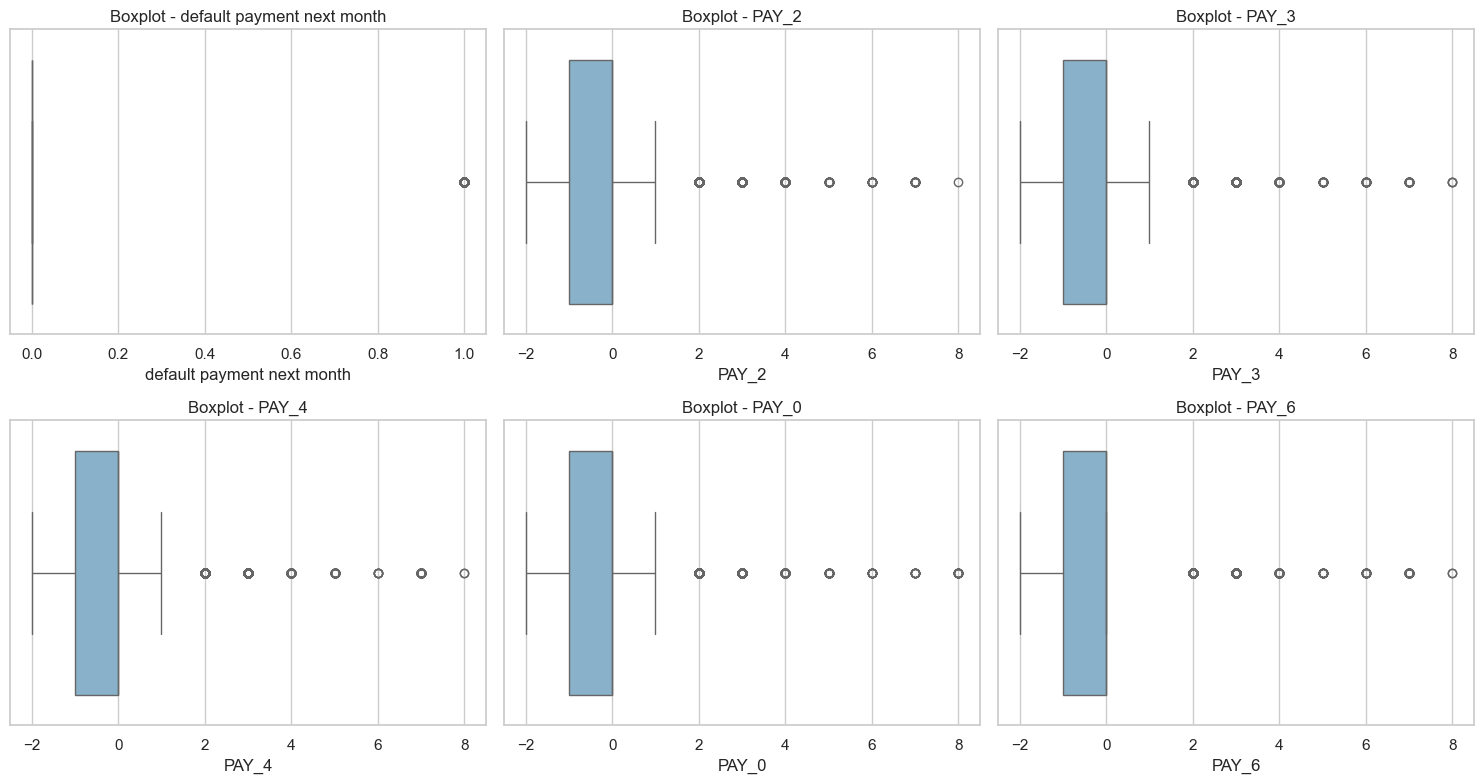

In [11]:
# 2) 이상치 탐색 (IQR 기준)
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

outlier_summary = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    out_cnt = int(mask.sum())
    out_ratio = round(out_cnt / len(df) * 100, 2)

    outlier_summary.append([col, out_cnt, out_ratio, lower, upper])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["feature", "outlier_count", "outlier_ratio(%)", "lower_bound", "upper_bound"]
).sort_values("outlier_ratio(%)", ascending=False)

display(outlier_df.head(20))

# 이상치 비율 상위 피처 박스플롯
top_outlier_cols = outlier_df.head(6)["feature"].tolist()
if top_outlier_cols:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(top_outlier_cols):
        sns.boxplot(x=df[col], ax=axes[i], color="#7FB3D5")
        axes[i].set_title(f"Boxplot - {col}")
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

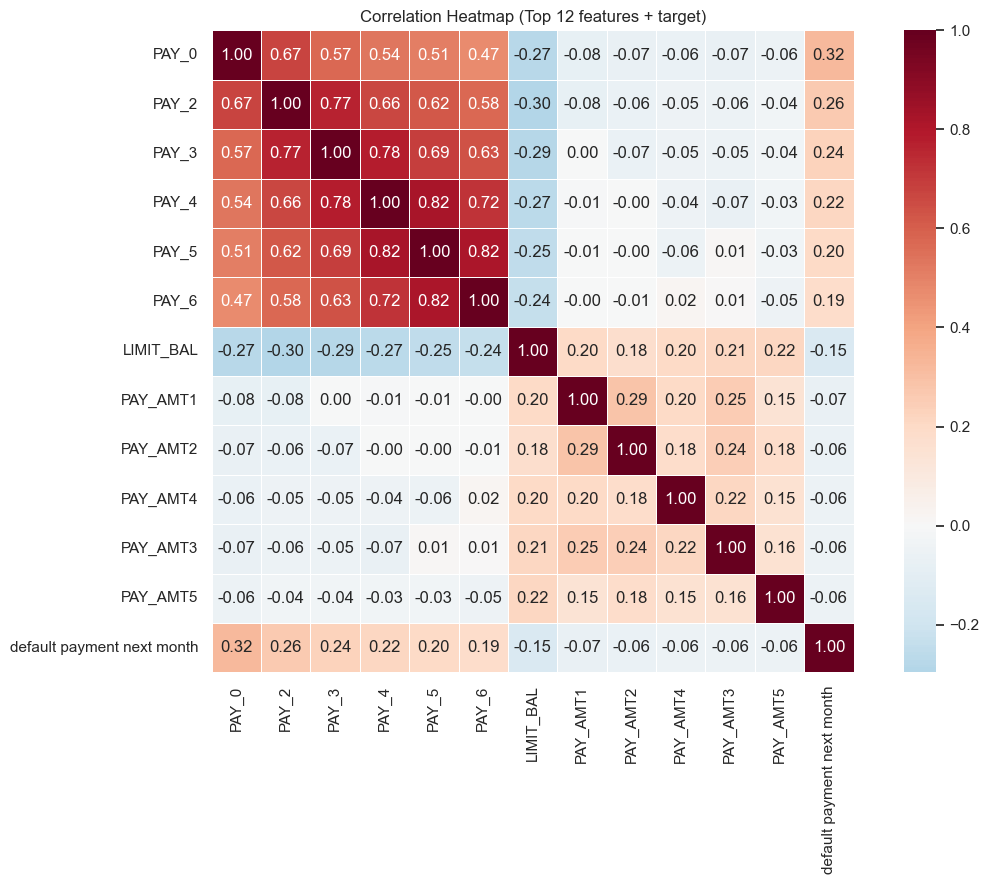

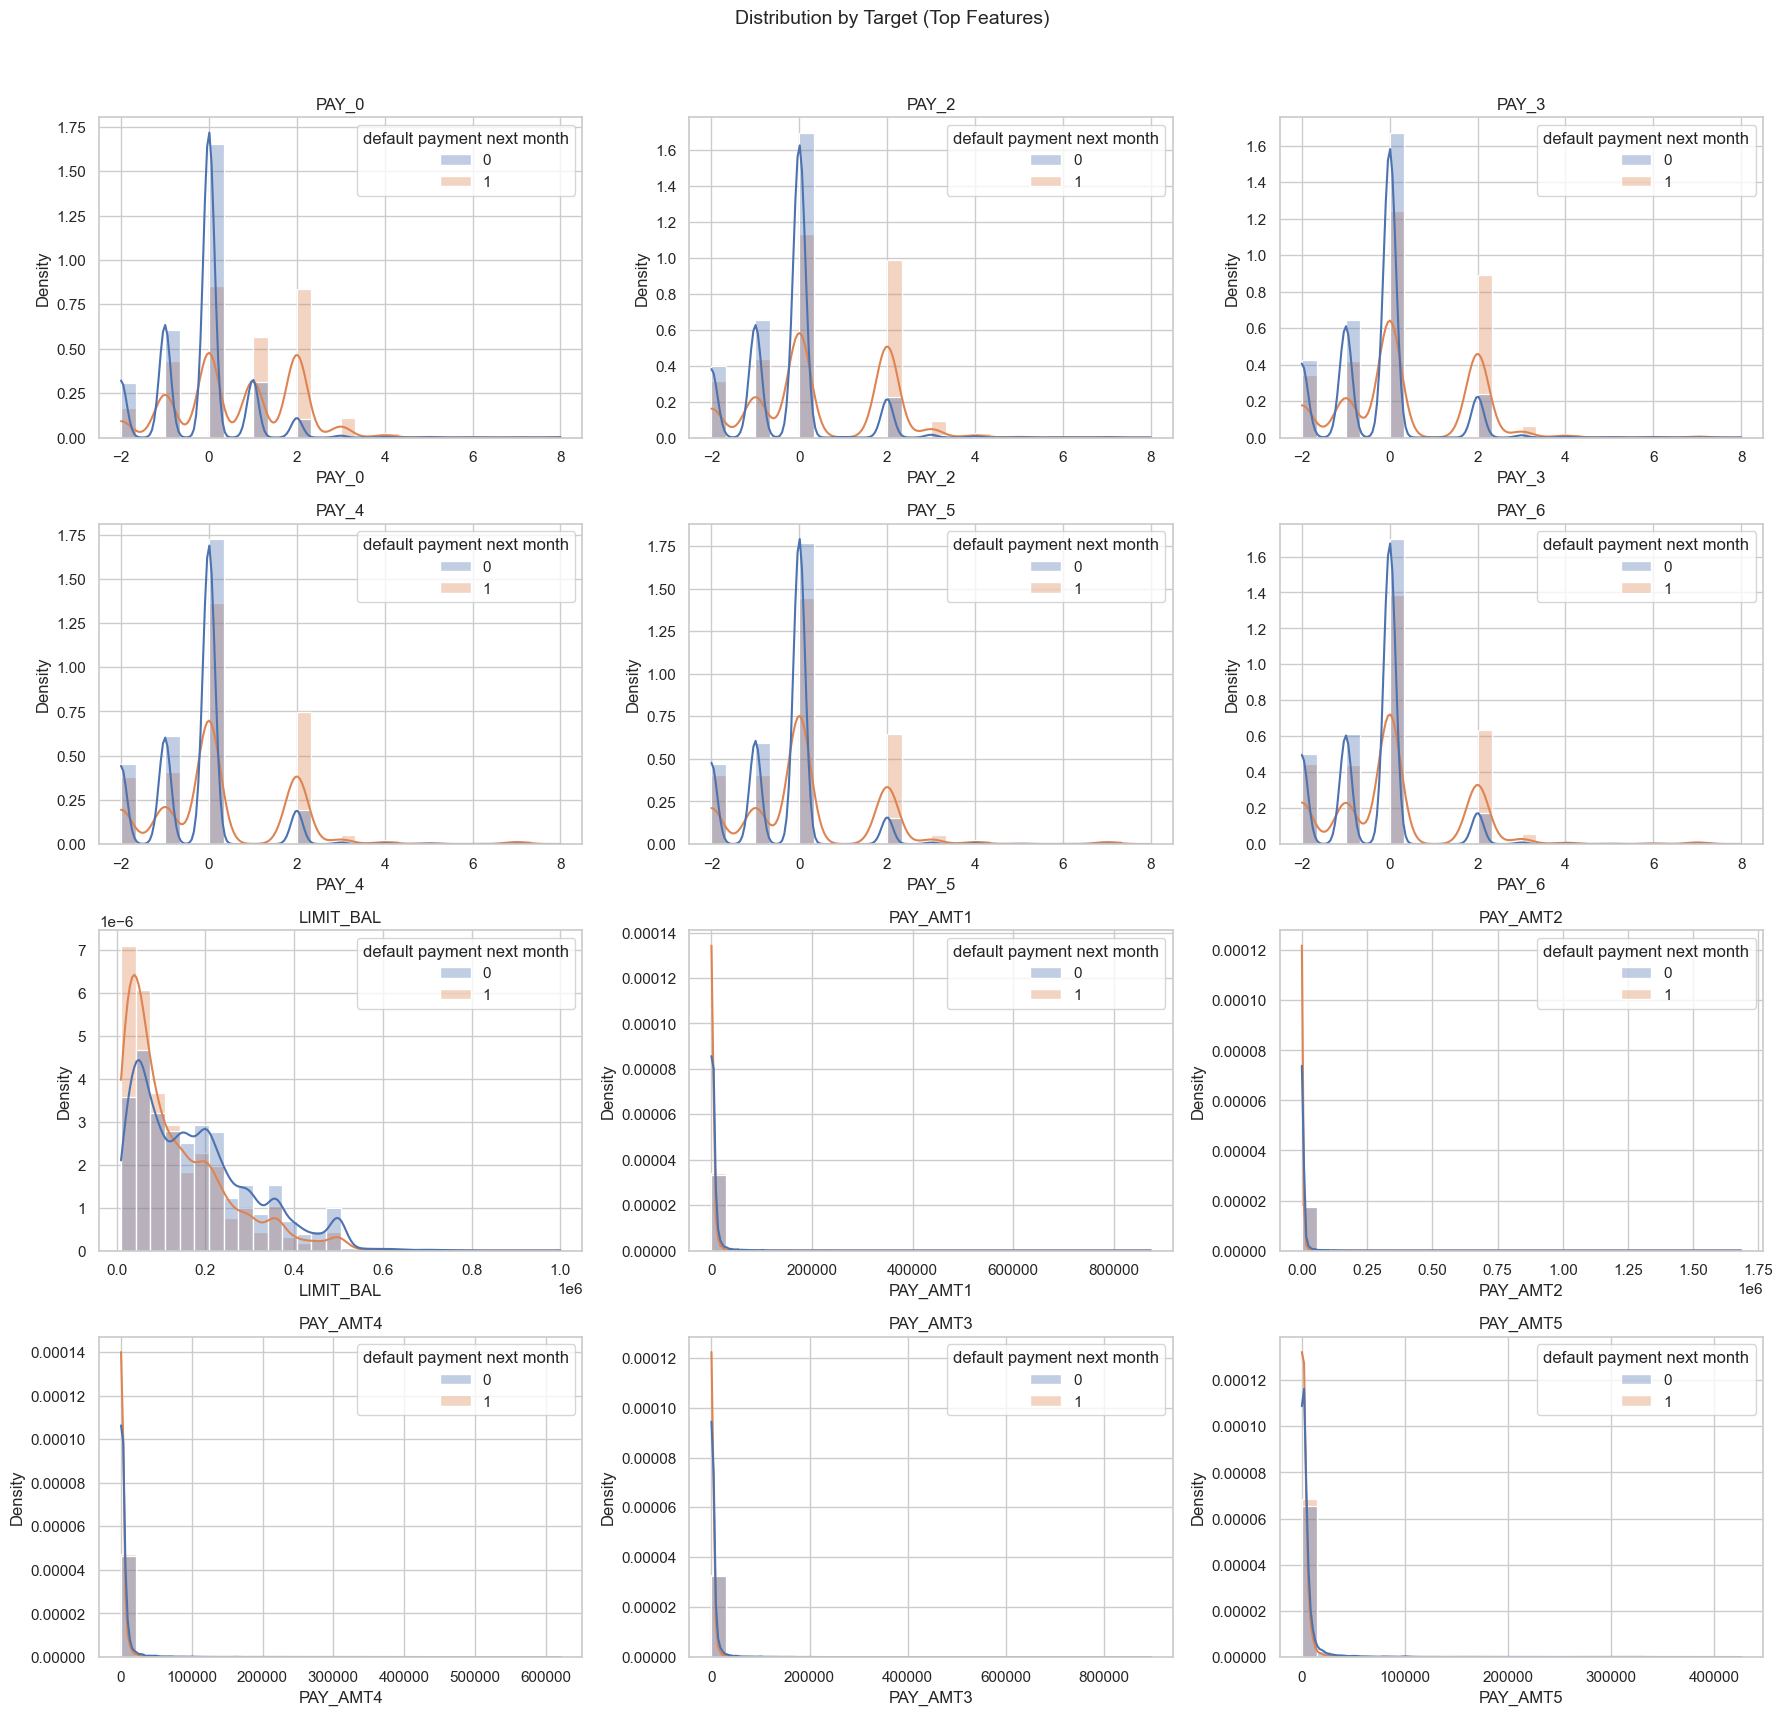

In [12]:
# 3) 주요 피처 분포 + 타깃 상관 시각화 (수정본)
target_col = "default payment next month"

if target_col not in df.columns:
    raise ValueError(f"'{target_col}' 컬럼이 없습니다. 컬럼 확인: {df.columns.tolist()}")

df_corr = df.copy()

# 타깃이 숫자가 아니면 인코딩
if not np.issubdtype(df_corr[target_col].dtype, np.number):
    df_corr[target_col], _ = pd.factorize(df_corr[target_col])

# 숫자형 피처
num_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

# 타깃과의 상관값 기준 주요 피처 선택
corr_with_target = (
    df_corr[num_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

# 3줄 이상이 되도록 기본 12개(4행 x 3열) 사용
top_n = 12
top_features = corr_with_target.head(top_n).index.tolist()

# 1) 상관관계 히트맵
heatmap_cols = top_features + [target_col]
corr_mat = df_corr[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title(f"Correlation Heatmap (Top {len(top_features)} features + target)")
plt.tight_layout()
plt.show()

# 2) Distribution by target: 3열 고정, 여러 행(최소 3행 이상)
n_cols = 3
n_rows = max(3, math.ceil(len(top_features) / n_cols))  # 최소 3행
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(top_features):
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=30,
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.35,
        ax=axes[i]
    )
    axes[i].set_title(col)

# 남는 축 숨기기
for j in range(len(top_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribution by Target (Top Features)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 2. 데이터 전처리

### 검토 결과 요약
| 항목 | 대상 컬럼 | 처리 방법 |
|------|-----------|----------|
| 불필요 컬럼 제거 | `ID` | 이미 제거 완료 ✓ |
| 범주형 인코딩 | `SEX`, `EDUCATION`, `MARRIAGE` | 이상값 정리 + One-Hot Encoding |
| 수치형 스케일링 | `LIMIT_BAL`, `AGE`, `BILL_AMT*`, `PAY_AMT*`, `PAY_*` | StandardScaler |

> **SEX**: 1/2 → 0/1 이진 변환  
> **EDUCATION**: 공식 범주(1~4) 외 0·5·6 값을 4(others)로 통합  
> **MARRIAGE**: 공식 범주(1~3) 외 0 값을 3(others)로 통합  

In [13]:
# 2-1. 범주형 피처 인코딩

X_enc = X_features.copy()

# ── (A) SEX: 1=male, 2=female → 0/1 이진 변환 ──────────────
X_enc['SEX'] = X_enc['SEX'].map({1: 0, 2: 1})  # 0=male, 1=female

# ── (B) EDUCATION 이상값 처리 ───────────────────────────────
# 공식 범주: 1=graduate, 2=university, 3=high school, 4=others
# 0·5·6 은 문서에 없는 값 → 4(others)로 통합
edu_valid = {1, 2, 3, 4}
X_enc['EDUCATION'] = X_enc['EDUCATION'].apply(
    lambda x: x if x in edu_valid else 4
)
print("EDUCATION 분포 (정리 후):")
print(X_enc['EDUCATION'].value_counts().sort_index())
print()

# ── (C) MARRIAGE 이상값 처리 ────────────────────────────────
# 공식 범주: 1=married, 2=single, 3=others
# 0 은 문서에 없는 값 → 3(others)으로 통합
mar_valid = {1, 2, 3}
X_enc['MARRIAGE'] = X_enc['MARRIAGE'].apply(
    lambda x: x if x in mar_valid else 3
)
print("MARRIAGE 분포 (정리 후):")
print(X_enc['MARRIAGE'].value_counts().sort_index())
print()

# ── (D) EDUCATION · MARRIAGE One-Hot Encoding ───────────────
X_enc = pd.get_dummies(
    X_enc,
    columns=['EDUCATION', 'MARRIAGE'],
    drop_first=False,      # 모든 더미 생성 (다중공선성은 모델이 처리)
    dtype=int
)

print(f"인코딩 후 shape: {X_enc.shape}")
print("생성된 더미 컬럼:")
dummy_cols = [c for c in X_enc.columns if 'EDUCATION_' in c or 'MARRIAGE_' in c]
print(dummy_cols)
X_enc.head(3)


EDUCATION 분포 (정리 후):
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE 분포 (정리 후):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

인코딩 후 shape: (30000, 28)
생성된 더미 컬럼:
['EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000,1,24,2,2,-1,-1,-2,-2,3913,...,0,0,0,0,1,0,0,1,0,0
1,120000,1,26,-1,2,0,0,0,2,2682,...,1000,0,2000,0,1,0,0,0,1,0
2,90000,1,34,0,0,0,0,0,0,29239,...,1000,1000,5000,0,1,0,0,0,1,0


In [14]:
# 2-2. 수치형 피처 스케일링 (StandardScaler)
from sklearn.preprocessing import StandardScaler

# 스케일링 대상: 연속형 + 순서형 수치 컬럼
# (One-Hot 더미 컬럼 및 이진화된 SEX는 제외)
scale_cols = (
    ['LIMIT_BAL', 'AGE']
    + [f'PAY_{s}' for s in [0, 2, 3, 4, 5, 6]]
    + [f'BILL_AMT{i}' for i in range(1, 7)]
    + [f'PAY_AMT{i}'  for i in range(1, 7)]
)

# 실제 존재하는 컬럼만 선택 (안전 처리)
scale_cols = [c for c in scale_cols if c in X_enc.columns]

scaler = StandardScaler()
X_enc[scale_cols] = scaler.fit_transform(X_enc[scale_cols])

print(f"스케일링 적용 컬럼 수: {len(scale_cols)}개")
print(scale_cols)
print()
print("스케일링 후 기술통계 (평균≈0, 표준편차≈1 확인):")
display(
    X_enc[scale_cols].describe().loc[['mean','std']].round(4)
)


스케일링 적용 컬럼 수: 20개
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

스케일링 후 기술통계 (평균≈0, 표준편차≈1 확인):


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
mean,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [15]:
# 2-3. 전처리 최종 결과 확인

print("="*55)
print(" 전처리 완료 요약")
print("="*55)
print(f" 원본  shape : {X_features.shape}")
print(f" 전처리 후    : {X_enc.shape}")
print()
print("[불필요 컬럼 제거]")
print("  - ID 컬럼: 이미 제거 완료 ✓")
print()
print("[범주형 인코딩]")
print("  - SEX       : 1/2 → 0/1 이진 변환 ✓")
print("  - EDUCATION : 이상값(0,5,6)→4 통합 + One-Hot(4개) ✓")
print("  - MARRIAGE  : 이상값(0)→3 통합  + One-Hot(3개) ✓")
print()
print("[수치형 스케일링]")
print(f"  - StandardScaler 적용: {len(scale_cols)}개 컬럼 ✓")
print("    (LIMIT_BAL, AGE, PAY_0~6, BILL_AMT1~6, PAY_AMT1~6)")
print()
print("[최종 컬럼 목록]")
for col in X_enc.columns:
    print(f"  {col}")
print()
print("결측치 확인:", X_enc.isnull().sum().sum(), "개")

# Train/Test split에 사용할 최종 변수 설정
X_final = X_enc.copy()
y_final = y_target.copy()
print()
print("=> X_final, y_final 로 이후 모델링에 사용하세요.")


 전처리 완료 요약
 원본  shape : (30000, 23)
 전처리 후    : (30000, 28)

[불필요 컬럼 제거]
  - ID 컬럼: 이미 제거 완료 ✓

[범주형 인코딩]
  - SEX       : 1/2 → 0/1 이진 변환 ✓
  - EDUCATION : 이상값(0,5,6)→4 통합 + One-Hot(4개) ✓
  - MARRIAGE  : 이상값(0)→3 통합  + One-Hot(3개) ✓

[수치형 스케일링]
  - StandardScaler 적용: 20개 컬럼 ✓
    (LIMIT_BAL, AGE, PAY_0~6, BILL_AMT1~6, PAY_AMT1~6)

[최종 컬럼 목록]
  LIMIT_BAL
  SEX
  AGE
  PAY_0
  PAY_2
  PAY_3
  PAY_4
  PAY_5
  PAY_6
  BILL_AMT1
  BILL_AMT2
  BILL_AMT3
  BILL_AMT4
  BILL_AMT5
  BILL_AMT6
  PAY_AMT1
  PAY_AMT2
  PAY_AMT3
  PAY_AMT4
  PAY_AMT5
  PAY_AMT6
  EDUCATION_1
  EDUCATION_2
  EDUCATION_3
  EDUCATION_4
  MARRIAGE_1
  MARRIAGE_2
  MARRIAGE_3

결측치 확인: 0 개

=> X_final, y_final 로 이후 모델링에 사용하세요.


모델링 시 주의사항

- Accuracy 만으로는 평가 불충분 → 모델이 전부 0으로 예측해도 77.9% 달성 가능
- Recall, F1-Score, ROC-AUC 를 주요 평가 지표로 사용
- 채무불이행(소수 클래스)을 놓치는 것이 비즈니스 손실이 크므로 Recall 이 특히 중요
- 필요 시 class_weight='balanced' 또는 오버샘플링(SMOTE) 적용 고려

# 3. Train / Test Split

In [27]:
# 3. Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final      # 클래스 비율 유지
)

print("=" * 45)
print(" Train / Test Split 결과")
print("=" * 45)
print(f" 전체  : {len(X_final):,}건")
print(f" Train : {len(X_train):,}건  ({len(X_train)/len(X_final):.0%})")
print(f" Test  : {len(X_test):,}건   ({len(X_test)/len(X_final):.0%})")
print()
print("클래스 비율 확인 (stratify 검증)")
print(f" Train 채무불이행 비율: {y_train.mean():.3f}")
print(f" Test  채무불이행 비율: {y_test.mean():.3f}")

 Train / Test Split 결과
 전체  : 30,000건
 Train : 24,000건  (80%)
 Test  : 6,000건   (20%)

클래스 비율 확인 (stratify 검증)
 Train 채무불이행 비율: 0.221
 Test  채무불이행 비율: 0.221


# SMOTE 오버샘플링

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


 SMOTE 적용 결과
 적용 전 Train: 24,000건
   정상(0)       : 18,691건
   채무불이행(1)  : 5,309건

 적용 후 Train: 37,382건
   정상(0)       : 18,691건
   채무불이행(1)  : 18,691건
 채무불이행 비율: 0.500


C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\754000952.py:39: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\754000952.py:39: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\754000952.py:39: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\754000952.py:39: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\754000952.py:39: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\754000952.py:39: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout(

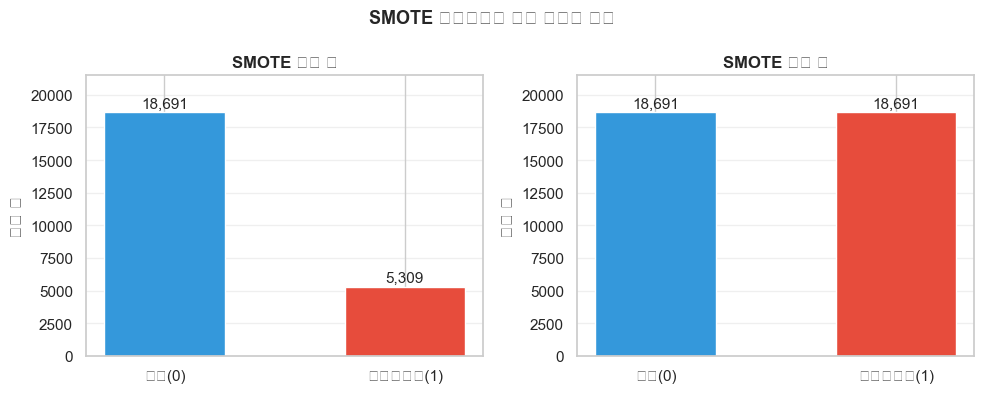

In [28]:
# 4-0. SMOTE 오버샘플링 (Train 셋에만 적용)
# pip install imbalanced-learn --break-system-packages
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("=" * 45)
print(" SMOTE 적용 결과")
print("=" * 45)
print(f" 적용 전 Train: {len(X_train):,}건")
print(f"   정상(0)       : {(y_train==0).sum():,}건")
print(f"   채무불이행(1)  : {(y_train==1).sum():,}건")
print()
print(f" 적용 후 Train: {len(X_train_sm):,}건")
print(f"   정상(0)       : {(y_train_sm==0).sum():,}건")
print(f"   채무불이행(1)  : {(y_train_sm==1).sum():,}건")
print(f" 채무불이행 비율: {y_train_sm.mean():.3f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [
    (y_train,    "SMOTE 적용 전"),
    (y_train_sm, "SMOTE 적용 후"),
]):
    counts = y.value_counts().sort_index()
    bars = ax.bar(['정상(0)', '채무불이행(1)'], counts.values,
                  color=['#3498DB', '#E74C3C'], edgecolor='white', width=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{v:,}', ha='center', va='bottom', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('샘플 수')
    ax.set_ylim(0, counts.max() * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SMOTE 오버샘플링 전후 클래스 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. 모델 학습

- **Logistic Regression** — 베이스라인
- **Random Forest** — 트리 앙상블
- **XGBoost** — 부스팅

> 클래스 불균형(4:1) 대응 → 각 모델에 `class_weight='balanced'` 또는 `scale_pos_weight` 적용

In [29]:
# 4-1. Logistic Regression (베이스라인)
from sklearn.linear_model import LogisticRegression

# class_weight 제거: SMOTE로 이미 균형 맞춤
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_sm, y_train_sm)   # SMOTE 적용 데이터

lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression 학습 완료 ✓")

Logistic Regression 학습 완료 ✓


In [30]:
# 4-2. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)   # SMOTE 적용 데이터

rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest 학습 완료 ✓")

Random Forest 학습 완료 ✓


In [31]:
# 4-3. XGBoost
from xgboost import XGBClassifier

# SMOTE로 균형 맞춤 → scale_pos_weight=1 (기본값)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_sm, y_train_sm)  # SMOTE 적용 데이터

xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost 학습 완료 ✓")

XGBoost 학습 완료 ✓


# 5. 모델 평가

- **Classification Report** — Accuracy, Precision, Recall, F1-Score
- **ROC-AUC Curve** — 불균형 데이터에서 특히 중요
- **Confusion Matrix** — 실제 예측 오류 패턴 확인

In [32]:
# ============================================================
# 5-1. Classification Report — 3모델 비교
# ============================================================
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

models_eval = {
    'Logistic Regression': (lr_pred,  lr_pred_proba),
    'Random Forest'      : (rf_pred,  rf_pred_proba),
    'XGBoost'            : (xgb_pred, xgb_pred_proba),
}

summary_rows = []

for name, (pred, proba) in models_eval.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred,
                                target_names=['정상(0)', '채무불이행(1)']))
    summary_rows.append({
        '모델'     : name,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall'   : recall_score(y_test, pred),
        'F1-Score' : f1_score(y_test, pred),
        'ROC-AUC'  : roc_auc_score(y_test, proba),
    })

summary_df = pd.DataFrame(summary_rows).set_index('모델')
print("\n=== 모델 성능 요약 ===")
display(summary_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

  Logistic Regression
              precision    recall  f1-score   support

       정상(0)       0.86      0.75      0.80      4673
    채무불이행(1)       0.40      0.58      0.47      1327

    accuracy                           0.71      6000
   macro avg       0.63      0.67      0.64      6000
weighted avg       0.76      0.71      0.73      6000

  Random Forest
              precision    recall  f1-score   support

       정상(0)       0.87      0.84      0.86      4673
    채무불이행(1)       0.50      0.56      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

  XGBoost
              precision    recall  f1-score   support

       정상(0)       0.85      0.90      0.88      4673
    채무불이행(1)       0.56      0.45      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.68      0.69      6000
weighted avg       0.79   

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
모델,,,,,
Logistic Regression,0.7140,0.3996,0.5833,0.4743,0.7148
Random Forest,0.7802,0.5027,0.5599,0.5298,0.7701
XGBoost,0.8002,0.5595,0.4537,0.5010,0.7619


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLA

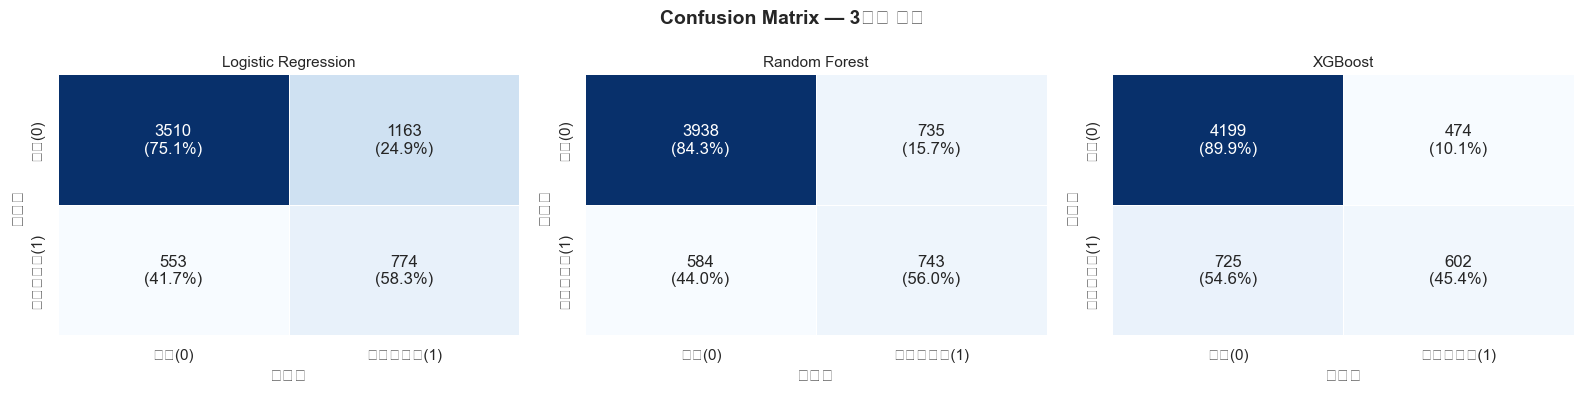

In [33]:
# 5-2. Confusion Matrix 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrix — 3모델 비교', fontsize=14, fontweight='bold')

for ax, (name, (pred, _)) in zip(axes, models_eval.items()):
    cm     = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    labels = np.array(
        [[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
         for row_v, row_p in zip(cm, cm_pct)]
    )
    sns.heatmap(
        cm, annot=labels, fmt='', cmap='Blues',
        xticklabels=['정상(0)', '채무불이행(1)'],
        yticklabels=['정상(0)', '채무불이행(1)'],
        ax=ax, cbar=False, linewidths=0.5
    )
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\3656944141.py:28: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\3656944141.py:28: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\3656944141.py:28: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18832\3656944141.py:28: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGU

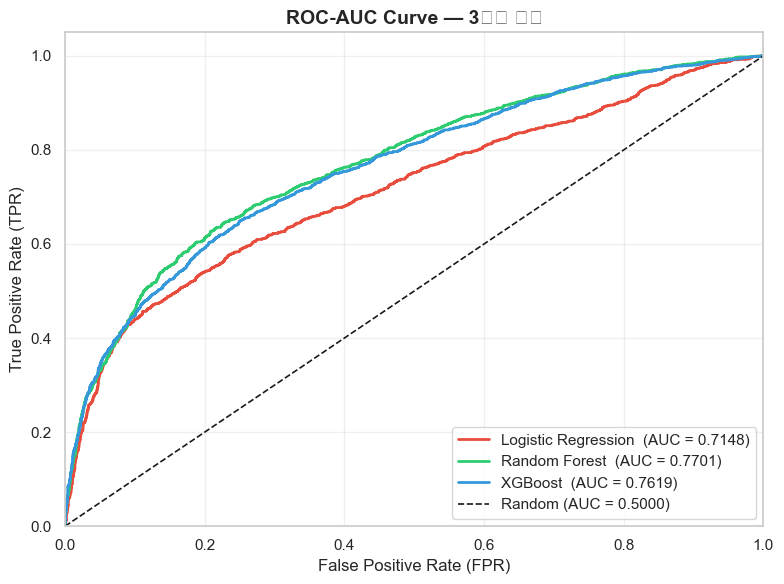

In [34]:
# 5-3. ROC-AUC Curve 시각화
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

colors = {
    'Logistic Regression': '#E74C3C',
    'Random Forest'      : '#2ECC71',
    'XGBoost'            : '#3498DB',
}

for name, (_, proba) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr,
             label=f"{name}  (AUC = {roc_auc:.4f})",
             color=colors[name], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-AUC Curve — 3모델 비교', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()